## Evaluation

This notebook compares zero-shot vs full-tune vs LoRA across 8 prompt variants

In [6]:
# imports
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np

In [23]:
# zero-shot: Directly use the model to predict, lora: finetune the model with LoRA, full: finetune the model with full fine-tuning
model_types = ['zeroshot', 'lora', 'full']
prompt_types = ["baseline", "role_based", "few_shot_base", "few_shot_role_based"]
cot_options = [False, True]

Assumes the predictions are in the directory "output/zeroshot", "output/lora", and "output/full". Each directory contains 8 csv files, one for each prompt type.

In [24]:
# load data
zeroshot_results = {}
lora_results = {}
full_tune_results = {}
model_results = {
    'zeroshot': zeroshot_results,
    'lora': lora_results, 
    'full': full_tune_results
}

for model_type in model_types:
    for prompt_type in prompt_types:
        for cot in cot_options:
            cot_str = 'True' if cot else 'False'
            filename = f"../output/{model_type}/Q2_20230202_majority_predictions_{prompt_type}_{cot_str}.csv"
            cot_key = "cot" if cot else "no_cot"
            key = f"{prompt_type}_{cot_key}"
            model_results[model_type][key] = pd.read_csv(filename)

In [25]:
result_list = []

for model_type, results in model_results.items():
    for prompt_type, df in results.items():
        y_true = df['label_majority']
        y_pred = df['prediction']
        accuracy = np.mean(y_true == y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        result_list.append({
            'model_type': model_type,
            'prompt_type': prompt_type,
            'accuracy': accuracy,
            'f1': f1
        })

result_df = pd.DataFrame(result_list)

In [30]:
result_df.head()

,model_type,prompt_type,accuracy,f1
0,zeroshot,baseline_no_cot,0.586854,0.412165
1,zeroshot,baseline_cot,0.586854,0.412165
2,zeroshot,role_based_no_cot,0.586681,0.414436
3,zeroshot,role_based_cot,0.586681,0.414436
4,zeroshot,few_shot_base_no_cot,0.571553,0.395534


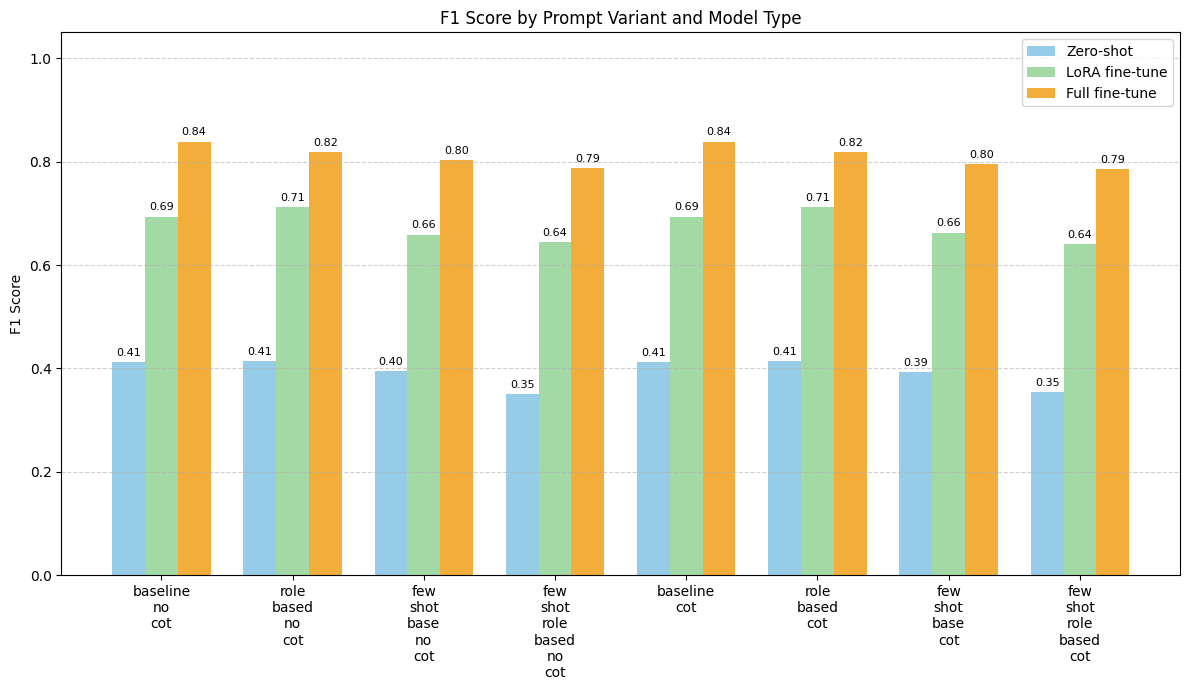

In [44]:
prompt_keys = ["baseline_no_cot", "role_based_no_cot", "few_shot_base_no_cot", "few_shot_role_based_no_cot",
                "baseline_cot", "role_based_cot", "few_shot_base_cot", "few_shot_role_based_cot"]
zero_shot_df = result_df[result_df['model_type'] == 'zeroshot'].set_index('prompt_type')
full_tune_df = result_df[result_df['model_type'] == 'full'].set_index('prompt_type')
lora_df = result_df[result_df['model_type'] == 'lora'].set_index('prompt_type')

zero_shot_val = [float(zero_shot_df.at[k, 'f1']) for k in prompt_keys]
full_tune_val = [float(full_tune_df.at[k, 'f1']) for k in prompt_keys]
lora_val = [float(lora_df.at[k, 'f1']) for k in prompt_keys]

       
x      = np.arange(len(prompt_keys))
width  = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width, zero_shot_val,   width,
               label="Zero-shot",  color="#97CCE8")
bars2 = ax.bar(x,          lora_val, width,
               label="LoRA fine-tune", color="#A3D9A5")
bars3 = ax.bar(x + width,  full_tune_val, width,
               label="Full fine-tune", color="#f2ad3b")

# annotate each bar with the value
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Prompt Variant and Model Type")
ax.set_xticks(x)
ax.set_xticklabels([p.replace("_", "\n") for p in prompt_keys], rotation=0)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [48]:
# best model and its performance
best = result_df.sort_values("f1", ascending=False).iloc[0]
print(f"Best model: {best['model_type']} with {best['prompt_type']}")
print(f"F1 score: {best['f1']}")
print(f"Accuracy: {best['accuracy']}")

Best model: full with baseline_cot
F1 score: 0.838847663528251
Accuracy: 0.870283428968875


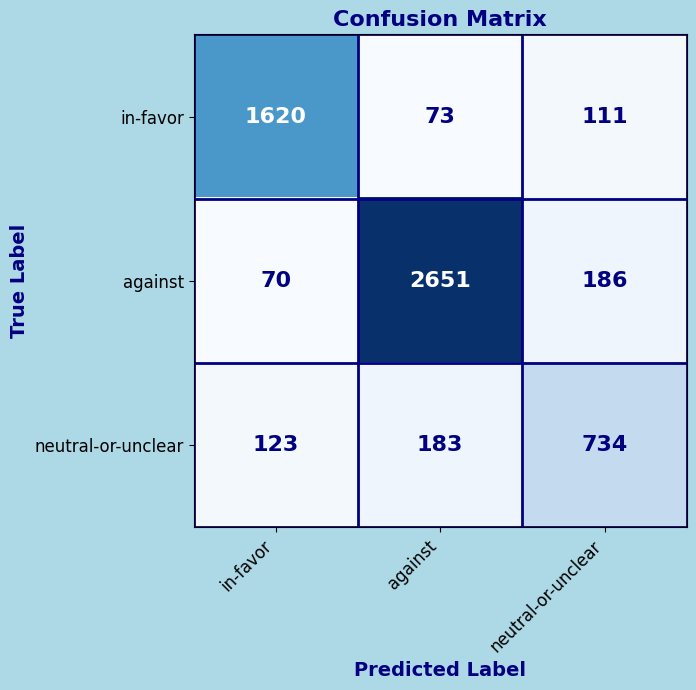

In [52]:
# confusion matrix for the best performance
y_true_best = model_results[best["model_type"]][best["prompt_type"]]["label_majority"]
y_pred_best = model_results[best["model_type"]][best["prompt_type"]]["prediction"]
cm = confusion_matrix(y_true_best, y_pred_best)

# plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('lightblue')

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# add text to the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'navy'
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center", 
                color=text_color, fontsize=16, fontweight='bold')
        
classes = ['in-favor', 'against', 'neutral-or-unclear']
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(classes, fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', color='navy')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold', color='navy')
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold', color='navy')

ax.set_xticks(np.arange(len(classes)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(classes)+1)-.5, minor=True)
ax.grid(which="minor", color="navy", linestyle='-', linewidth=2)
ax.tick_params(which="minor", size=0)

plt.tight_layout()
plt.show()